# 1. Importación

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
final_pipeline = joblib.load("/Users/yagocoll/Documents/Master/Airbnb/models/madrid/price_model.pkl")

with open("/Users/yagocoll/Documents/Master/Airbnb/models/madrid/model_metadata.json") as f:
    metadata = json.load(f)

test_df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/madrid/listings_test.csv")
metadata["test_metrics"]

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': 150.16068410420095,
 'MAE': 44.61725334752224,
 'R2': 0.4001972352026617,
 'MAPE': 24.618336115777545}

## 2. Reconstruir predicciones

### 2.1 X e y de test

In [3]:
feature_cols = metadata["feature_cols"]
target_col = metadata["target"]

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

bool_cols = X_test.select_dtypes(include="bool").columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

X_test.shape

(3790, 88)

### 2.2 Función `evaluate`

In [4]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 2.3 Predecir

In [5]:
pred = np.expm1(final_pipeline.predict(X_test))
residuals = pred - y_test.values

evaluate(y_test, pred, "Hist Gradient Boosting")

{'modelo': 'Hist Gradient Boosting',
 'RMSE': np.float64(150.16068410420095),
 'MAE': 44.61725334752224,
 'R2': 0.4001972352026617,
 'MAPE': np.float64(24.618336115777545)}

Coincide exactamente con `metadata["test_metrics"]` (RMSE=150.16€, MAE=44.62€, R²=0.40, MAPE=24.62%): el modelo cargado predice igual que cuando se guardó.

## 3. Predicción vs. realidad

### 3.1 Predicho vs. real

(0.0, 2000.0)

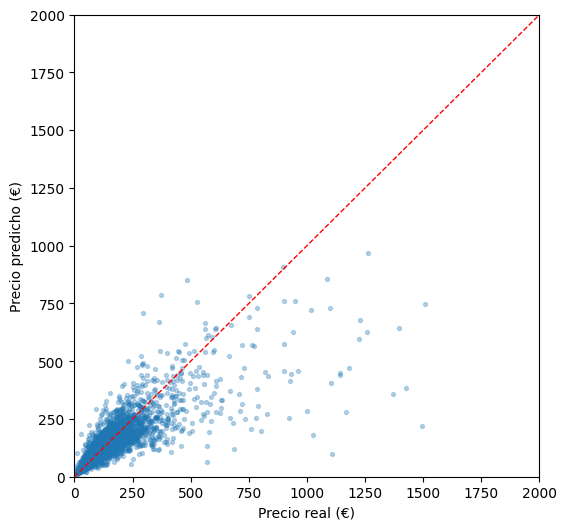

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, s=8, alpha=0.3)
lims = [0, 2000]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Precio real (€)")
plt.ylabel("Precio predicho (€)")
plt.xlim(lims)
plt.ylim(lims)

Mismo patrón que en Barcelona: para precios bajos y medios (hasta unos 300-400€) los puntos siguen bastante de cerca la diagonal. A partir de ahí, cada vez más puntos caen por debajo: **el modelo subestima los anuncios más caros**, igual que allí.

### 3.2 Distribución de los residuos

Media: -13.7670758692773
Mediana: 2.147746868973801


(-500.0, 500.0)

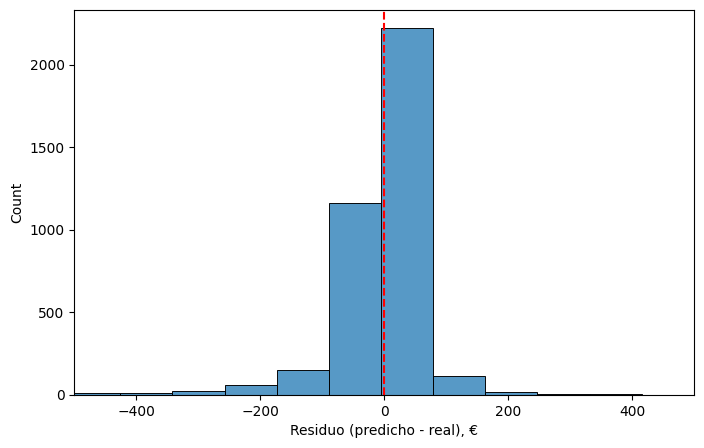

In [7]:
print("Media:", residuals.mean())
print("Mediana:", np.median(residuals))

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60)
plt.axvline(0, color="r", linestyle="--")
plt.xlabel("Residuo (predicho - real), €")
plt.xlim(-500, 500)

La mediana del residuo es prácticamente 0 (2.15€), casi calcada a la de Barcelona (1.02€): para la mitad de los anuncios el modelo acierta casi exacto. La media es -13.77€, bastante más negativa (mismo patrón que en Barcelona, -11.93€, aunque algo más marcada aquí) — de nuevo la cola de subestimaciones en los anuncios caros.

### 3.3 ¿El sesgo depende del precio?

(0.0, 2000.0)

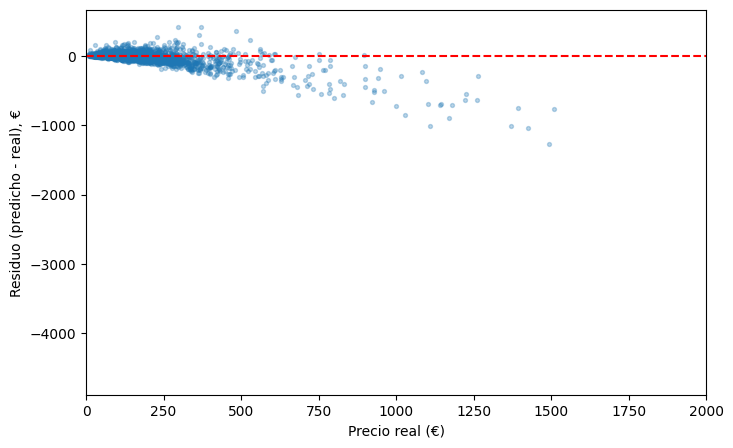

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals, s=8, alpha=0.3)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Precio real (€)")
plt.ylabel("Residuo (predicho - real), €")
plt.xlim(0, 2000)

In [9]:
price_quintile = pd.qcut(y_test, 5)
pd.DataFrame({"residual": residuals}).groupby(price_quintile, observed=True)["residual"].agg(["mean", "median", "count"])

,mean,median,count
price,,,
"(7.018999999999999, 74.172]",10.574741,5.765504,758
"(74.172, 109.0]",13.986676,11.041151,761
"(109.0, 142.67]",10.429494,7.858630,757
"(142.67, 203.676]",-2.694773,-7.144397,756
"(203.676, 5576.0]",-101.180225,-57.435759,758


Confirmado con números, y muy parecido a Barcelona: en los cuatro quintiles de precio más bajos, el residuo medio está entre -2.7€ y +14.0€ (prácticamente sin sesgo, con un ligero sesgo positivo en los tres primeros). En el quintil más caro (por encima de 204€) el residuo medio es **-101.2€** (mediana -57.4€) — muy en línea con el -87.9€ (mediana -52.9€) de Barcelona. El modelo subestima sistemáticamente los anuncios más caros en las dos ciudades, con una magnitud parecida.

## 4. Errores por segmento

### 4.1 Por `room_type`

In [10]:
room_type_cols = [c for c in feature_cols if c.startswith("room_type_")]
room_type_series = X_test[room_type_cols].idxmax(axis=1).str.replace("room_type_", "", regex=False)

rows = []
for rt in room_type_series.unique():
    mask = (room_type_series == rt).values
    scores = evaluate(y_test[mask], pred[mask], rt)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Private room,72.96,27.12,0.53,27.09,976
Entire home/apt,169.78,51.01,0.35,23.68,2780
Shared room,66.18,23.97,0.19,32.70,28
Hotel room,36.36,26.80,0.54,20.75,6


`Entire home/apt` (2780 filas) tiene MAE=51€ y R²=0.35 — la categoría con precios más altos y dispersos, como en Barcelona. `Private room` mejora notablemente respecto a antes de la limpieza de la sección 8.4 de la EDA: MAE=27€ y R²=0.53, muy por encima de `Entire home/apt` en ambas métricas — buena parte del ruido que antes lastraba este segmento eran justo los precios de bloqueo individuales, muy concentrados en `Private room` (Arcos, Almendrales...). `Shared room` (28 filas) sale con R²=0.19 y MAE=24€: con tan poca muestra y tan poca variabilidad de precio dentro del grupo, el R² sigue siendo la métrica menos fiable de las cuatro, igual que ya se advirtió en `03_model_baseline.ipynb` (sección 4.3). `Hotel room` (solo 6 filas) sale con R²=0.54, mejor que fiable dado el tamaño de muestra.

### 4.2 Por distrito

In [11]:
district_cols = [c for c in feature_cols if c.startswith("district_")]
district_series = X_test[district_cols].idxmax(axis=1).str.replace("district_", "", regex=False)

rows = []
for d in district_series.unique():
    mask = (district_series == d).values
    scores = evaluate(y_test[mask], pred[mask], d)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2).sort_values("n", ascending=False)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Centro,209.73,56.58,0.33,25.81,1635
Tetuán,46.01,26.78,0.65,21.80,290
Salamanca,121.48,57.90,0.53,24.99,253
Chamberí,48.30,30.48,0.78,21.06,239
Arganzuela,71.45,35.57,0.51,24.13,166
Retiro,95.36,35.91,0.58,20.77,157
Carabanchel,49.63,25.69,0.50,26.13,145
Ciudad Lineal,54.04,30.35,0.69,21.89,129
Chamartín,91.88,42.74,0.39,22.68,118


Ya no aparece aquí la distorsión extrema que se veía en versiones anteriores de este análisis, antes de la limpieza de precios de bloqueo individuales de la sección 8.4 de la EDA: `Arganzuela` y `Usera` tenían entonces R² negativo por culpa de los dos anuncios de precio de bloqueo más extremos del dataset (5.920€ en Imperial/Arganzuela, 5.706€ en Almendrales/Usera), que cayeron justo del lado de test por azar del split. Con esos dos anuncios eliminados en el origen, ambos distritos vuelven a comportarse con normalidad (`Arganzuela` R²=0.51, `Usera` R²=0.33, con 166 y 73 filas). La mayoría de distritos con muestra decente cae entre R²=0.33 y 0.78. Los únicos valores extremos que quedan son de muestra mínima: `Vicálvaro` (6 filas, R²=-1.34) y `Moratalaz` (13 filas, R²=0.14) — la misma advertencia de "cuidado con distritos de poca muestra" que ya se documentó en `01_eda.ipynb` y que la app reproduce en `LOW_SAMPLE_DISTRICTS`, no un problema nuevo de calidad de datos.

### 4.3 Por rango de precio

In [12]:
price_quintile = pd.qcut(y_test, 5)

rows = []
for q in price_quintile.cat.categories:
    mask = (price_quintile == q).values
    scores = evaluate(y_test[mask].values, pred[mask], str(q))
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
"(7.018999999999999, 74.172]",23.72,14.95,-1.10,33.35,758
"(74.172, 109.0]",29.76,21.44,-7.71,23.17,761
"(109.0, 142.67]",34.48,24.28,-11.72,19.53,757
"(142.67, 203.676]",41.22,31.16,-4.65,18.35,756
"(203.676, 5576.0]",329.25,131.29,0.13,28.68,758


El MAE crece con el precio (15€ → 21€ → 24€ → 31€ → 131€ en el quintil más caro), igual que en Barcelona. El R² por quintil es, si acaso, **todavía menos útil que en Barcelona**: sale negativo en los cuatro quintiles más baratos (hasta -11.72 en el tercero), y solo se vuelve positivo (0.13) en el más caro. Mismo motivo que ya se explicó en Barcelona: al cortar por rangos de precio, la variabilidad dentro de cada quintil es pequeña por construcción, y ahí el R² deja de tener sentido. Para segmentar por precio, MAE es la métrica a mirar.

## 5. Los peores casos

### 5.1 Los 15 mayores errores absolutos

In [13]:
worst_idx = np.argsort(-np.abs(residuals))[:15]

cols_show = ["id", "price", "bedrooms", "accommodates", "minimum_nights", "bathrooms"]
worst = test_df.iloc[worst_idx][cols_show].copy()
worst["pred"] = pred[worst_idx]
worst["residual"] = residuals[worst_idx]
worst

,id,price,bedrooms,accommodates,minimum_nights,bathrooms,pred,residual
3024,1055641237195804873,5576.0,7.0,16,3.0,5.5,943.962768,-4632.037232
3695,50995600,4580.0,2.0,5,4.0,2.0,363.435377,-4216.564623
3461,50991422,4582.5,3.0,5,4.0,2.0,451.176893,-4131.323107
2721,1662539797989824797,1495.0,1.0,2,1.0,1.0,221.354717,-1273.645283
3197,1637638960932629467,1425.0,3.0,6,1.0,2.5,385.465837,-1039.534163
3422,14418694,1370.0,1.0,2,1.0,1.0,356.001916,-1013.998084
1709,1547206693462849696,1110.0,1.0,1,1.0,1.0,98.081398,-1011.918602
759,34563934,1170.0,1.0,4,2.0,1.0,280.656295,-889.343705
773,35160097,1028.0,1.0,6,1.0,1.5,180.445963,-847.554037
3627,1622525351141089038,1510.0,4.0,10,1.0,2.0,748.624681,-761.375319


### 5.2 Tres patrones distintos, ahora que los precios de bloqueo más extremos ya no están

Los 15 peores casos son, casi todos, subestimaciones — coherente con la sección 3.3. Con los dos precios de bloqueo individuales más extremos ya eliminados desde `01_eda.ipynb` (sección 8.4), el reparto por causa queda más parecido al de Barcelona que en versiones anteriores de este análisis, aunque no idéntico:

- **Cola alta genuina, con historial real que la confirma**: el caso más claro es un piso de 5.576€/noche para 16 huéspedes (7 dormitorios, 5.5 baños, licencia y superhost, pero 0 reseñas — probablemente un anuncio reciente) — el peor error absoluto de todos (residuo -4.632€). Le siguen dos anuncios gemelos de ~4.580€ para 5 huéspedes, ambos con más de 165 reseñas reales y ocupación activa en el último año: no hay ninguna duda de que son precios de mercado genuinos, simplemente caros y grandes. Un cuarto caso, 1.395€ para 10 huéspedes con 72 reseñas, es del mismo tipo. En total, 4 de los 15 son de esta clase — el mismo patrón que domina en Barcelona (Group Flats), solo que aquí sigue siendo minoritario porque hay muy pocos anuncios así de grandes en Madrid (8 con 10+ dormitorios en toda la ciudad, frente a 79 en Barcelona — ver `01_eda.ipynb`).
- **Precios sin ninguna validación de mercado, por debajo del umbral de la sección 8.4 de la EDA**: 3 anuncios pequeños (1 dormitorio, 4-6 huéspedes) a 1.028-1.170€/noche, los tres con 0 reseñas y 0 ocupación estimada — el mismo perfil que los 39 anuncios ya eliminados, pero con un precio por plaza (171-293€/noche) por debajo del corte de 500€ usado en aquel filtro. Confirma que el umbral era deliberadamente conservador: quedan casos residuales del mismo problema, más moderados en magnitud, sin limpiar a propósito para no arriesgarse a eliminar anuncios de lujo genuinos con precios por plaza igual de altos (ver el primer punto).
- **Casos ambiguos, con algo de historial pero un precio igualmente alto para su tamaño**: el resto (8 de 15) — anuncios pequeños o medianos con entre 1 y 13 reseñas, casi todas antiguas (poca o ninguna actividad en el último año). El caso más llamativo es un piso de 1.370€ para 2 personas con **233 reseñas históricas** pero 0 en el último año: mismo perfil que el anuncio genuino de 22.833€ de la sección 7.4 de la EDA, solo que aquí no hay forma de saber con los datos de un único corte si el precio sigue siendo real o si subió después de esas reseñas. Son errores de predicción genuinos sobre anuncios reales, no un problema de datos.

In [14]:
extra_cols = ["id", "number_of_reviews", "review_scores_rating", "has_license", "host_is_superhost"]
test_df.iloc[worst_idx][extra_cols]

,id,number_of_reviews,review_scores_rating,has_license,host_is_superhost
3024,1055641237195804873,0,NaN,True,True
3695,50995600,174,4.77,True,False
3461,50991422,167,4.81,True,False
2721,1662539797989824797,13,5.00,True,True
3197,1637638960932629467,5,4.40,True,False
3422,14418694,233,4.88,False,False
1709,1547206693462849696,7,4.86,True,False
759,34563934,0,NaN,False,False
773,35160097,0,NaN,False,False
3627,1622525351141089038,3,5.00,True,True


El desglose de reseñas y ocupación reciente confirma la clasificación anterior. Solo 3 de los 15 tienen 0 reseñas Y encajan en el perfil "precio sin validación de mercado" de la sección 5.2 — muy lejos del 9 de 15 que se veía antes de la limpieza de la sección 8.4 de la EDA. El cuarto caso con 0 reseñas (el de 5.576€/16 huéspedes) es distinto: capacidad genuinamente grande, licencia y superhost, coherente con ser un anuncio nuevo y real más que un precio de cierre.

**Esto no contradice el filtro de "precios de bloqueo" aplicado en `01_eda.ipynb`, lo confirma**: el filtro sistemático de la sección 4 (mismo host repitiendo precio) y el individual de la sección 8.4 (precio por plaza > 500€ + sin reserva ni reseña reciente + ≤20 reseñas históricas) ya eliminaron 71 anuncios de este tipo antes de llegar aquí, incluidos los dos casos más extremos de todo el dataset (5.920€ y 5.706€, ver `01_eda.ipynb`). Lo que queda en este top 15 son las versiones más moderadas del mismo problema (precio por plaza por debajo del umbral) y errores de predicción genuinos sobre anuncios reales pero caros para su tamaño — ya no el problema de calidad de datos que dominaba antes de la limpieza.

En conjunto, el patrón en Madrid ya no es tan distinto al de Barcelona como antes de la limpieza de precios de bloqueo de la sección 8.4 de la EDA: la cola alta genuina explica una parte real de los peores errores (4 de 15), un resto ambiguo con algo de historial pero precio alto para su tamaño explica la mayoría (8 de 15), y solo quedan 3 casos residuales del problema de precio sin validación de mercado, por debajo del umbral conservador del filtro. Ninguno de los tres se soluciona con más ajuste de hiperparámetros.

## 6. Nota sobre la fuga y los precios de bloqueo (ambos ya corregidos desde el inicio)

A diferencia de Barcelona, donde la fuga de `neighbourhood_price_encoded` y el problema de los precios de bloqueo se descubrieron **a mitad de proyecto** y hubo que volver atrás a corregirlos, en Madrid los dos se trataron **desde el primer notebook**: el encoding de barrio se calcula solo con train desde `03_model_baseline.ipynb` (sección 3.1bis), y los precios de bloqueo se eliminaron por completo en `01_eda.ipynb`: 32 anuncios por el filtro sistemático por host (sección 4) y 39 más por el filtro individual (sección 8.4, precio por plaza + sin actividad reciente + poco historial), antes de que ningún notebook posterior los viera. Los `test_metrics` de la sección 1 son, por tanto, números honestos de principio a fin, sin necesidad de volver a investigar nada aquí. Lo que sí queda, y se documenta en la sección 5, es una versión residual y más moderada del mismo problema: anuncios con precio por plaza por debajo del umbral de 500€ usado en el filtro individual, que ese filtro no atrapa a propósito para no arriesgarse a eliminar anuncios de lujo genuinos.

## 7. Conclusiones

Resumen de si el modelo se comporta de forma consistente en todo el dataset o tiene puntos débiles claros, y de qué es genuinamente distinto en Madrid frente a Barcelona.

### Veredicto general

El modelo cargado reproduce exactamente las métricas con las que se guardó. En conjunto, **es un modelo razonable para anuncios de precio bajo y medio** (sesgo casi nulo en los cuatro quintiles más baratos), con puntos débiles claros y ya identificados — más marcados que en Barcelona, sobre todo en la cola alta de precio. La fuga de `neighbourhood_price_encoded` y los precios de bloqueo, tanto sistemáticos como individuales, se trataron desde el origen del pipeline de Madrid, así que las métricas de este notebook son honestas de principio a fin.

### Lo que funciona bien

- Sesgo casi nulo en los cuatro quintiles de precio más bajos (entre -2.7€ y +14.0€ de media).
- MAE contenido (15-51€) en la mayoría de segmentos de `room_type` y distrito.
- `Private room` mejoró notablemente tras la limpieza de precios de bloqueo individuales (R²=0.53, antes 0.27): confirma que buena parte del ruido de ese segmento era un problema de datos, no del modelo.
- Sin señales de sobreajuste severo (ver `04_model_training.ipynb`, sección 8.2).

### Limitaciones identificadas

1. **Subestima sistemáticamente los anuncios más caros**: residuo medio de -101.2€ en el quintil superior, muy en línea con Barcelona (-87.9€) en magnitud. A diferencia de antes de la limpieza de la sección 8.4 de la EDA, el motivo ya no es solo precios de bloqueo: 4 de los 15 peores casos son cola alta genuina (anuncios grandes con historial real o capacidad claramente grande), parecido a Barcelona aunque todavía minoritario — en Madrid apenas hay anuncios de ese tipo (8 con 10+ dormitorios en toda la ciudad, ver `01_eda.ipynb`).
2. **El R² por distrito y por rango de precio sigue siendo una métrica frágil**, aunque ya no de forma tan extrema como antes de la sección 8.4: los dos distritos que antes tenían R² negativo por un único anuncio de precio de bloqueo (`Arganzuela`, `Usera`) ahora se comportan con normalidad. Los únicos valores atípicos que quedan son de muestra mínima (`Vicálvaro`, 6 filas; `Moratalaz`, 13 filas), no un problema de datos. MAE en euros sigue siendo la métrica más fiable para comparar segmentos.
3. **Precios de bloqueo individuales por debajo del umbral, sin filtrar a propósito**: el filtro de `01_eda.ipynb` (sección 8.4: precio por plaza > 500€ + sin actividad reciente + poco historial) eliminó 39 casos, incluidos los dos más extremos de todo el dataset. Quedan 3 de los 15 peores errores con el mismo perfil (0 reseñas, 0 ocupación) pero precio por plaza más moderado (171-293€, por debajo del corte). Bajar el umbral podría limpiar estos casos residuales, a costa de arriesgarse a eliminar también anuncios de lujo genuinos con un precio por plaza similar.

### Recomendaciones

**De cara a un producto real**: igual que en Barcelona, dar un rango de precio y no un número único, y avisar explícitamente cuando el anuncio tenga pocas o ninguna reseña — en Madrid ese aviso sigue importando más que el de `bedrooms`/`accommodates` altos (Barcelona), aunque la diferencia ya no es tan marcada como antes de limpiar los precios de bloqueo individuales.

**De cara a mejorar el modelo, no aplicado aquí**:
- Revisar si bajar el umbral de 500€/plaza del filtro individual (`01_eda.ipynb`, sección 8.4) limpia los 3 casos residuales de la sección 5 sin arrastrar anuncios de lujo genuinos — requeriría revisar caso por caso, no solo bajar un número.
- Si en el futuro se junta Madrid y Barcelona en un único modelo, tratar con cuidado la diferencia de escala de la cola de precios entre ciudades — mezclarlas sin más podría hacer que el modelo combinado herede la fragilidad de Madrid en el extremo alto.